EDA

Взяли готовый датасет с yolo разметкой, удалили повторы, оставили один класс- транспортные средства


Импорт датасета


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


импорт библиотек, директории файлов

In [ ]:
import os
from PIL import Image, ImageStat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import random
from skimage.metrics import structural_similarity as ssim
import seaborn as sns

dataset_path = '/content/drive/MyDrive/Dataset'
images_dir = f"{dataset_path}/images"
labels_dir = f"{dataset_path}/labels"

проверка разрешения


In [ ]:


# Получаем список всех изображений
image_files = sorted(os.listdir(images_dir))

def get_image_size(image_path):
    with Image.open(image_path) as img:
        return img.size  # (ширина, высота)

# Считаем размеры всех изображений
image_sizes = [get_image_size(os.path.join(images_dir, img)) for img in image_files]

# Преобразуем в DataFrame
image_sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])

# Выводим уникальные размеры изображений
unique_sizes = image_sizes_df.value_counts().reset_index()
unique_sizes.columns = ['Width', 'Height', 'Count']
print(unique_sizes)

   Width  Height  Count
0   1920    1200   5103


несовпадает количество изображений, я так и не понял почему некоторые файлы продублировались при скачивание датасета, пришлось исправлять

In [ ]:
# Проверка на дубликаты
image_files_set = set(image_files)
label_files_set = set(label_files)

print(f"Number of unique image files: {len(image_files_set)}")
print(f"Number of unique label files: {len(label_files_set)}")

Number of unique image files: 5115
Number of unique label files: 5123


удалим лишнее

In [ ]:



def remove_files_with_parentheses(directory):
    files = os.listdir(directory)
    to_delete = []  # Список файлов для удаления

    for file in files:
        if '(' in file and ')' in file:  # Проверяем, если в имени файла есть скобки
            to_delete.append(file)  # Добавляем файл для удаления

    # Печатаем список файлов, которые должны быть удалены
    print("Файлы для удаления:", to_delete)

    # Удаляем найденные файлы
    for file in to_delete:
        file_path = os.path.join(directory, file)
        print(f"Удаляю файл: {file_path}")  # Логируем удаление
        os.remove(file_path)

# Удаляем файлы с () в названии в папке изображений
remove_files_with_parentheses(images_dir)

Файлы для удаления: []


удаляем дубликаты разметки


In [ ]:


# Папки с изображениями и метками
images_dir = "/content/drive/MyDrive/Dataset/images"
labels_dir = "/content/drive/MyDrive/Dataset/labels"

# Функция для удаления меток без пары в папке с изображениями
def remove_unmatched_labels(images_dir, labels_dir):
    # Получаем список всех изображений и меток
    image_files = set(os.listdir(images_dir))
    label_files = os.listdir(labels_dir)

    # Проходим по меткам и проверяем наличие соответствующих изображений
    for label in label_files:
        # Убираем расширение у метки (например, 10444.txt -> 10444)
        image_name = label.replace(".txt", ".jpg")  # Допустим, что изображения .jpg
        if image_name not in image_files:  # Если изображения нет в папке images
            label_path = os.path.join(labels_dir, label)
            print(f"Удаляю метку: {label_path}")
            os.remove(label_path)  # Удаляем метку

# Удаляем метки без пары в папке images
remove_unmatched_labels(images_dir, labels_dir)

Удаляю метку: /content/drive/MyDrive/Dataset/labels/14803 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/14817 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/14432 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/13188 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/12296 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/14181 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/10654 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/13836 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/10132 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/12043 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/11358 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/12137 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/10739 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/11341 (1).txt
Удаляю метку: /content/drive/MyDrive/Dataset/labels/14546 (1).txt
Удаляю мет

проверяем заново


In [ ]:



# Получаем список всех изображений
image_files = sorted(os.listdir(images_dir))

# Функция для получения размера изображения
def get_image_size(image_path):
    with Image.open(image_path) as img:
        return img.size  # (ширина, высота)

# Считаем размеры всех изображений
image_sizes = [get_image_size(os.path.join(images_dir, img)) for img in image_files]

# Преобразуем в DataFrame
image_sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])

# Выводим уникальные размеры изображений
unique_sizes = image_sizes_df.value_counts().reset_index()
unique_sizes.columns = ['Width', 'Height', 'Count']
print(unique_sizes)

   Width  Height  Count
0   1920    1200   5103


построим график расположения транспортных средств на изображениях

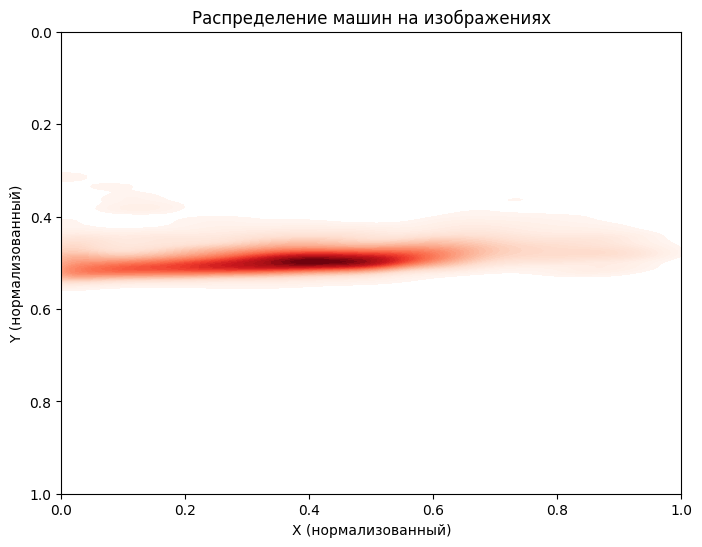

In [ ]:


# Получаем список файлов
image_files = sorted(os.listdir(images_dir))
label_files = sorted(os.listdir(labels_dir))

# Создаем списки для хранения координат
x_centers = []
y_centers = []

# Читаем разметку
for label_file in label_files:
    label_path = os.path.join(labels_dir, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        data = line.strip().split()
        if len(data) < 5:
            continue  # Пропускаем неправильные строки

        x_center, y_center = float(data[1]), float(data[2])  # YOLO-координаты (нормализованные)
        x_centers.append(x_center)
        y_centers.append(y_center)

# Преобразуем в массив
x_centers = np.array(x_centers)
y_centers = np.array(y_centers)

# Строим тепловую карту распределения машин
plt.figure(figsize=(8, 6))
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, levels=50)
plt.title("Распределение машин на изображениях")
plt.xlabel("X (нормализованный)")
plt.ylabel("Y (нормализованный)")
plt.xlim(0, 1)
plt.ylim(1, 0)  # Переворачиваем ось Y (чтобы было, как в картинках)
plt.show()

построим гистограммы с информацией о площаде, длинне, ширине объектов


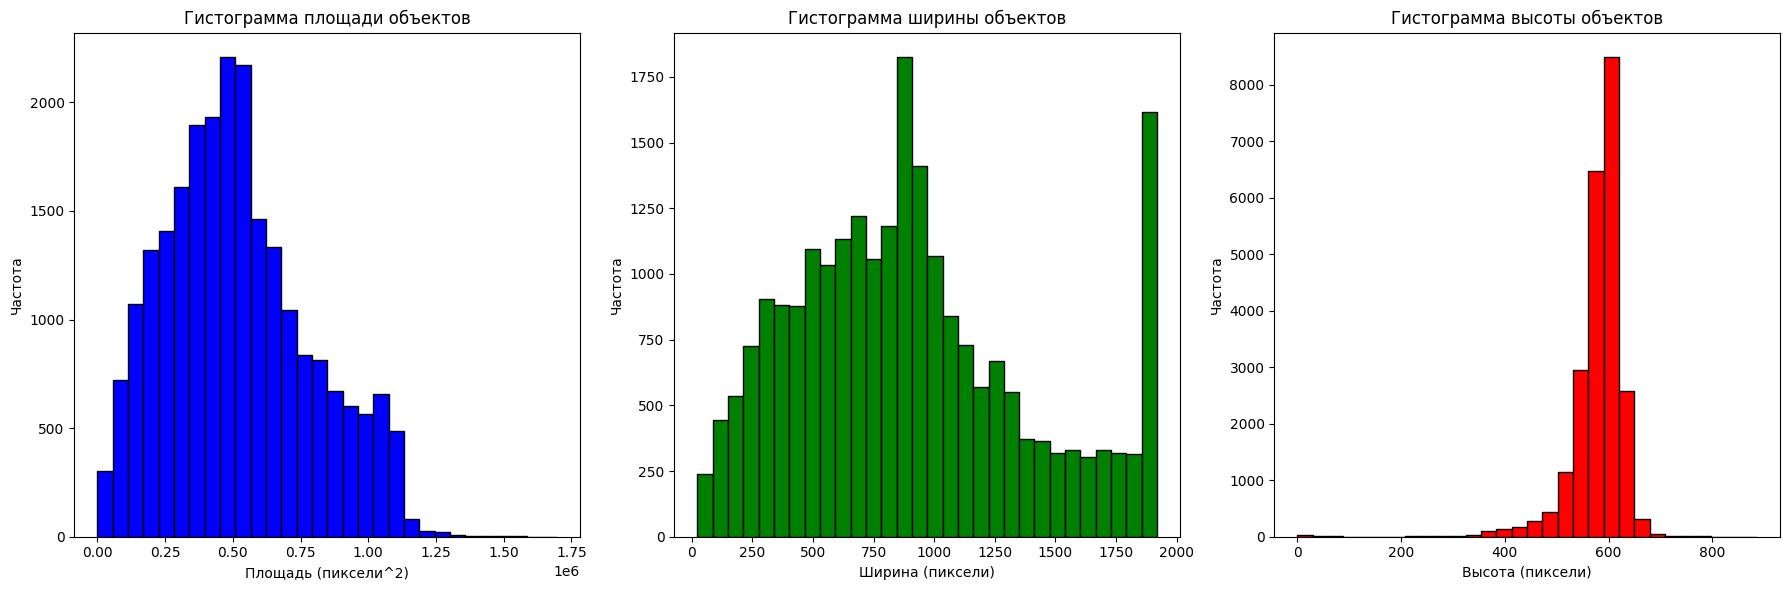

In [ ]:


# Размер изображения (фиксирован)
image_width = 1920
image_height = 1200

# Списки для хранения характеристик
areas = []
widths = []
heights = []

# Читаем разметку
label_files = sorted(os.listdir(labels_dir))
for label_file in label_files:
    label_path = os.path.join(labels_dir, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        data = line.strip().split()
        if len(data) < 5:
            continue  # Пропускаем неправильные строки

        # Получаем координаты и размеры (нормализованные)
        x_center, y_center, box_width, box_height = float(data[1]), float(data[2]), float(data[3]), float(data[4])

        # Преобразуем нормализованные координаты в пиксели
        box_width_pixel = box_width * image_width
        box_height_pixel = box_height * image_height

        # Вычисляем площадь, ширину и высоту
        area = box_width_pixel * box_height_pixel
        widths.append(box_width_pixel)
        heights.append(box_height_pixel)
        areas.append(area)

# Преобразуем в массивы
areas = np.array(areas)
widths = np.array(widths)
heights = np.array(heights)

# Строим гистограммы
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Гистограмма площади объектов
axs[0].hist(areas, bins=30, color='blue', edgecolor='black')
axs[0].set_title("Гистограмма площади объектов")
axs[0].set_xlabel("Площадь (пиксели^2)")
axs[0].set_ylabel("Частота")

# Гистограмма ширины объектов
axs[1].hist(widths, bins=30, color='green', edgecolor='black')
axs[1].set_title("Гистограмма ширины объектов")
axs[1].set_xlabel("Ширина (пиксели)")
axs[1].set_ylabel("Частота")

# Гистограмма высоты объектов
axs[2].hist(heights, bins=30, color='red', edgecolor='black')
axs[2].set_title("Гистограмма высоты объектов")
axs[2].set_xlabel("Высота (пиксели)")
axs[2].set_ylabel("Частота")

# Показываем графики
plt.tight_layout()
plt.show()

Гистограммы яркости
Для яркости перевели изображения в градации серого->среднее значение градации пикселей


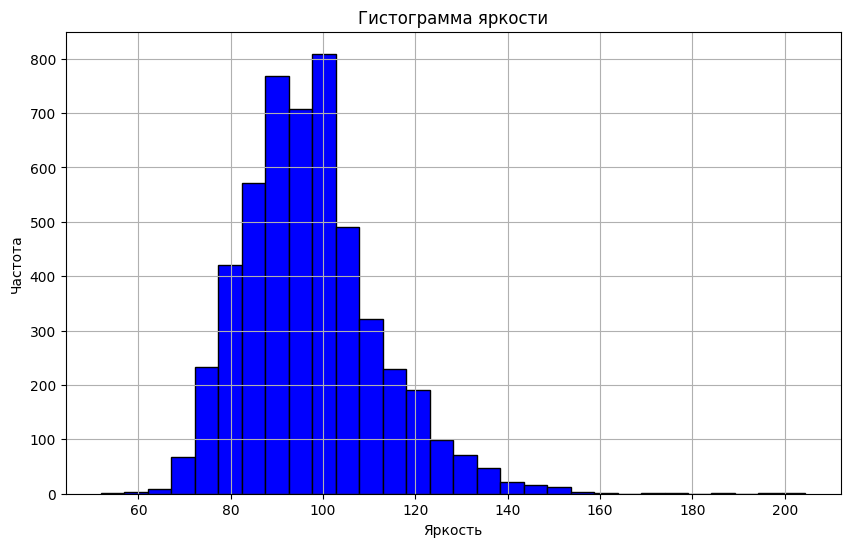

In [ ]:


# Путь к папке с изображениями
images_dir = "/content/drive/MyDrive/Dataset/images"

# Проверяем, существует ли папка
if not os.path.exists(images_dir):
    raise FileNotFoundError(f"Папка '{images_dir}' не найдена.")

# Получаем список файлов изображений
image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

# Список для хранения яркости
brightness = []

# Читаем изображения
for image_file in image_files:
    image_path = os.path.join(images_dir, image_file)

    try:
        # Загружаем изображение и переводим в оттенки серого
        img = Image.open(image_path).convert('L')

        # Вычисляем среднюю яркость
        stat = ImageStat.Stat(img)
        brightness.append(stat.mean[0])

    except Exception as e:
        print(f"Ошибка при обработке {image_file}: {e}")

# Преобразуем в массив
brightness = np.array(brightness)

# Строим гистограмму яркости
plt.figure(figsize=(10, 6))
plt.hist(brightness, bins=30, color='blue', edgecolor='black')
plt.title("Гистограмма яркости")
plt.xlabel("Яркость")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

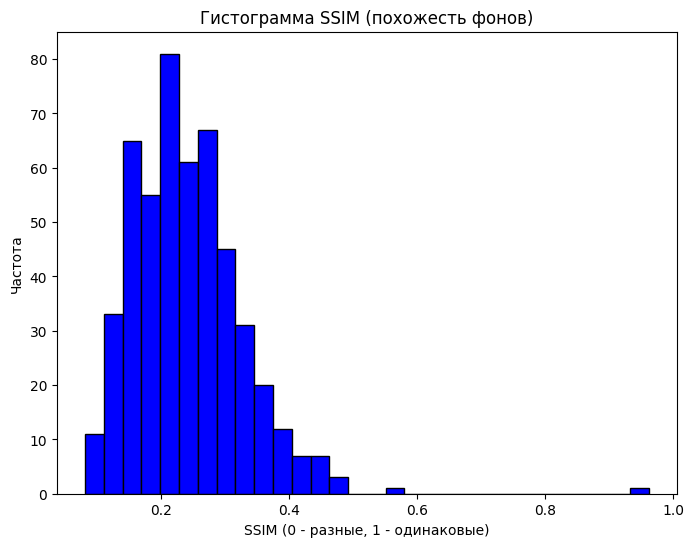

In [ ]:


# Берем 100 случайных изображений
num_samples = min(100, len(image_files))
sample_files = random.sample(image_files, num_samples)

# Функция для загрузки изображения в оттенках серого
def load_image_gray(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return cv2.resize(img, (300, 300))  # Приводим к единому размеру

# Считаем SSIM для случайных пар изображений
ssim_values = []
num_pairs = 500  # Сколько пар сравнивать (чтобы ускорить расчет)

for _ in range(num_pairs):
    img1, img2 = random.sample(sample_files, 2)  # Берем две случайные картинки
    img1 = load_image_gray(os.path.join(images_dir, img1))
    img2 = load_image_gray(os.path.join(images_dir, img2))

    score, _ = ssim(img1, img2, full=True)  # Считаем SSIM
    ssim_values.append(score)

# Строим гистограмму SSIM
plt.figure(figsize=(8, 6))
plt.hist(ssim_values, bins=30, color='blue', edgecolor='black')
plt.title("Гистограмма SSIM (похожесть фонов)")
plt.xlabel("SSIM (0 - разные, 1 - одинаковые)")
plt.ylabel("Частота")
plt.show()

# **Выводы(предварительные)**

# **Датасет имеет 5103 изображений, без дубликатов, все изображения имеют разрешение 1920 на 1200 пикселей, размечен один класс-транспортные средства**

# **Объекты класса в основном расположены вдоль середины изображения,имеют разную размерность**

# **Яркость сбалансирована, изображения имеют низкую схожесть фона**